# 03. Anàlisi de teleconnexions i variabilitat climàtica

Aquest notebook analitza la relació entre tres patrons de teleconnexió atmosfèrica i les anomalies climàtiques regionals:

- NAO
- WeMO
- ENSO/RONI

L'objectiu és identificar quins patrons tenen una relació més clara amb la temperatura, la precipitació, la humitat del sòl i la temperatura superficial del mar al Mediterrani occidental.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path("..") if Path("../data_processed").exists() else Path(".")
PROC = BASE / "data_processed"
FIG = BASE / "figures"
FIG.mkdir(parents=True, exist_ok=True)

DATA_PATH = PROC / "teleconnections_catalonia_1981_2020_main_v2.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["data"])

ordre_estacions = ["Winter", "Spring", "Summer", "Autumn"]
ordre_periodes = ["1981-1990", "1991-2000", "2001-2010", "2011-2020"]
ordre_fases = ["Negative", "Neutral", "Positive"]
ordre_enso = ["La Nina", "Neutral", "El Nino"]

df["estacio"] = pd.Categorical(df["estacio"], categories=ordre_estacions, ordered=True)
df["periode"] = pd.Categorical(df["periode"], categories=ordre_periodes, ordered=True)
df["fase_nao"] = pd.Categorical(df["fase_nao"], categories=ordre_fases, ordered=True)
df["fase_wemo"] = pd.Categorical(df["fase_wemo"], categories=ordre_fases, ordered=True)
df["fase_enso"] = pd.Categorical(df["fase_enso"], categories=ordre_enso, ordered=True)

print(df.shape)
df.head()

(1920, 38)


,data,any,mes,dies_mes,estacio,periode,subregio,nao,wemo,roni,...,anomalia_sst,mes_molt_calid,mes_molt_fred,mes_molt_sec,mes_molt_humit,sol_molt_sec,sol_molt_humit,episodi_calid_i_sec,episodi_fred_i_humit,episodi_calid_i_sol_sec
0,1981-01-01,1981,1,31,Winter,1981-1990,Llevant_Iberic,1.00,1.27,0.0,...,-0.891328,False,True,False,False,True,False,False,False,False
1,1981-02-01,1981,2,28,Winter,1981-1990,Llevant_Iberic,1.04,-0.18,-0.3,...,-0.814626,False,True,False,False,True,False,False,False,False
2,1981-03-01,1981,3,31,Spring,1981-1990,Llevant_Iberic,0.01,0.48,-0.3,...,-0.302593,True,False,False,False,True,False,False,False,True
3,1981-04-01,1981,4,30,Spring,1981-1990,Llevant_Iberic,-3.04,-1.36,-0.3,...,-0.168856,False,False,False,True,False,True,False,False,False
4,1981-05-01,1981,5,31,Spring,1981-1990,Llevant_Iberic,0.05,1.69,-0.3,...,-1.155891,False,True,False,False,False,True,False,False,False


In [2]:
tele_vars = ["nao", "wemo", "roni"]
clim_vars = [
    "anomalia_temperatura",
    "anomalia_precipitacio_mensual_mm",
    "anomalia_humitat_sol_capa1",
    "anomalia_sst",
]

rows = []

for tele in tele_vars:
    for var in clim_vars:
        cor = df[[tele, var]].corr().iloc[0, 1]
        rows.append({
            "teleconnexio": tele,
            "variable": var,
            "correlacio": cor,
        })

corr_global = pd.DataFrame(rows)
corr_global["etiqueta"] = corr_global["teleconnexio"] + " - " + corr_global["variable"]

display(corr_global)

corr_global.to_csv(PROC / "03_correlacions_globals_v2.csv", index=False)

,teleconnexio,variable,correlacio,etiqueta
0,nao,anomalia_temperatura,0.195331,nao - anomalia_temperatura
1,nao,anomalia_precipitacio_mensual_mm,-0.312271,nao - anomalia_precipitacio_mensual_mm
2,nao,anomalia_humitat_sol_capa1,-0.223200,nao - anomalia_humitat_sol_capa1
3,nao,anomalia_sst,0.114184,nao - anomalia_sst
4,wemo,anomalia_temperatura,-0.236772,wemo - anomalia_temperatura
5,wemo,anomalia_precipitacio_mensual_mm,-0.021647,wemo - anomalia_precipitacio_mensual_mm
6,wemo,anomalia_humitat_sol_capa1,-0.032614,wemo - anomalia_humitat_sol_capa1
7,wemo,anomalia_sst,-0.258013,wemo - anomalia_sst
8,roni,anomalia_temperatura,0.050773,roni - anomalia_temperatura
9,roni,anomalia_precipitacio_mensual_mm,0.012660,roni - anomalia_precipitacio_mensual_mm


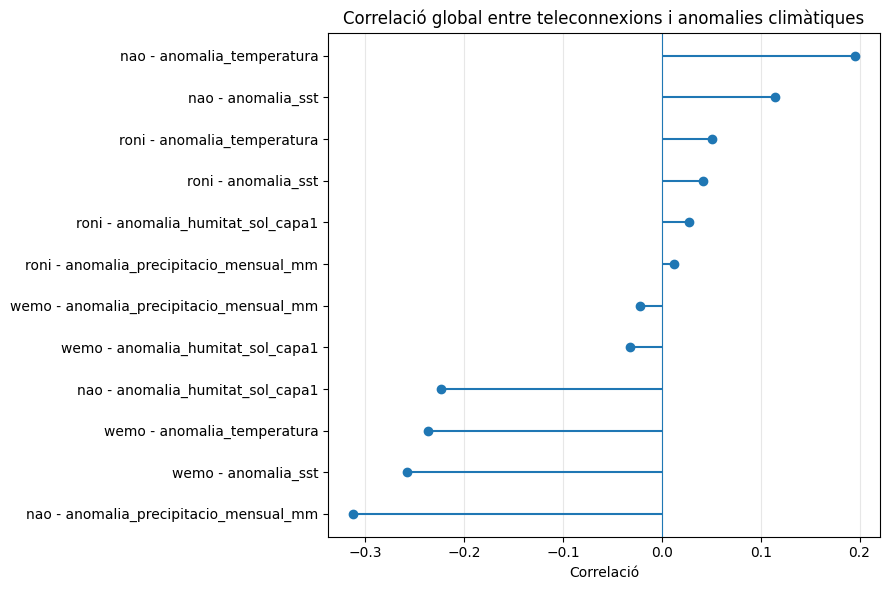

In [3]:
plot_df = corr_global.sort_values("correlacio")

fig, ax = plt.subplots(figsize=(9, 6))

y = np.arange(len(plot_df))
ax.hlines(y=y, xmin=0, xmax=plot_df["correlacio"])
ax.plot(plot_df["correlacio"], y, "o")
ax.axvline(0, linewidth=0.8)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["etiqueta"])
ax.set_xlabel("Correlació")
ax.set_title("Correlació global entre teleconnexions i anomalies climàtiques")
ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG / "03_correlacions_globals.png", dpi=300)
plt.show()

In [4]:
rows = []

for estacio in ordre_estacions:
    subset = df[df["estacio"] == estacio]

    for tele in tele_vars:
        for var in clim_vars:
            cor = subset[[tele, var]].corr().iloc[0, 1]
            rows.append({
                "estacio": estacio,
                "teleconnexio": tele,
                "variable": var,
                "correlacio": cor,
            })

corr_estacions = pd.DataFrame(rows)
display(corr_estacions.head())

corr_estacions.to_csv(PROC / "03_correlacions_per_estacio_v2.csv", index=False)

,estacio,teleconnexio,variable,correlacio
0,Winter,nao,anomalia_temperatura,0.317916
1,Winter,nao,anomalia_precipitacio_mensual_mm,-0.455861
2,Winter,nao,anomalia_humitat_sol_capa1,-0.387158
3,Winter,nao,anomalia_sst,0.315764
4,Winter,wemo,anomalia_temperatura,0.033835


In [5]:
label_vars = {
    "anomalia_temperatura": "Temp.",
    "anomalia_precipitacio_mensual_mm": "Precip.",
    "anomalia_humitat_sol_capa1": "Humitat sòl",
    "anomalia_sst": "SST",
}

label_tele = {
    "nao": "NAO",
    "wemo": "WeMO",
    "roni": "RONI",
}

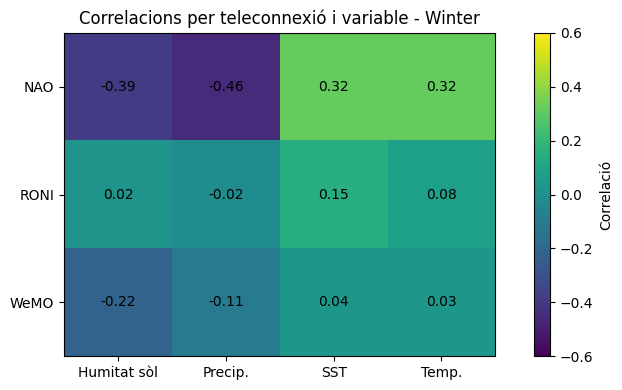

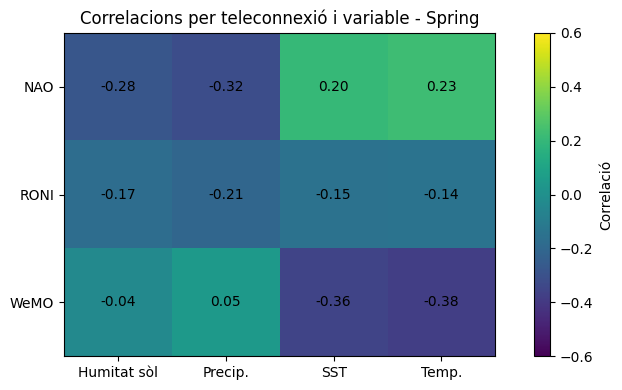

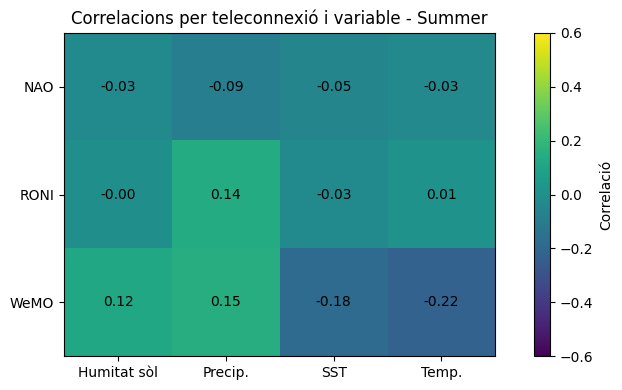

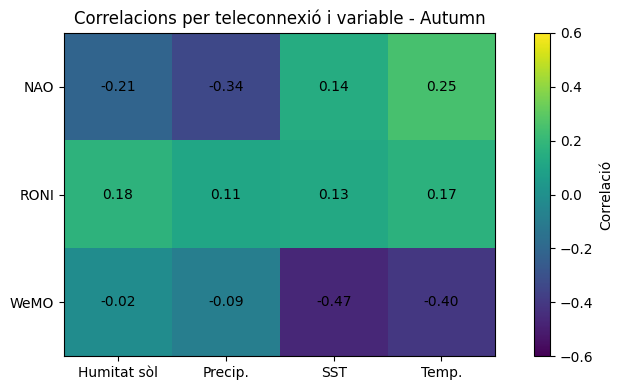

In [6]:
for estacio in ordre_estacions:
    temp = (
        corr_estacions[corr_estacions["estacio"] == estacio]
        .pivot(index="teleconnexio", columns="variable", values="correlacio")
    )

    fig, ax = plt.subplots(figsize=(8, 4))
    im = ax.imshow(temp, vmin=-0.6, vmax=0.6)

    ax.set_xticks(np.arange(len(temp.columns)))
    ax.set_yticks(np.arange(len(temp.index)))

    ax.set_xticklabels(
        [label_vars.get(c, c) for c in temp.columns],
        rotation=0
    )
    ax.set_yticklabels(
        [label_tele.get(i, i) for i in temp.index]
    )

    for i in range(len(temp.index)):
        for j in range(len(temp.columns)):
            ax.text(j, i, f"{temp.iloc[i, j]:.2f}", ha="center", va="center")

    ax.set_title(f"Correlacions per teleconnexió i variable - {estacio}")
    plt.colorbar(im, ax=ax, label="Correlació")

    plt.tight_layout()
    plt.savefig(FIG / f"03_heatmap_correlacions_{estacio}.png", dpi=300)
    plt.show()

In [7]:
rows = []

for subregio in df["subregio"].unique():
    subset = df[df["subregio"] == subregio]

    for tele in tele_vars:
        for var in clim_vars:
            cor = subset[[tele, var]].corr().iloc[0, 1]
            rows.append({
                "subregio": subregio,
                "teleconnexio": tele,
                "variable": var,
                "correlacio": cor,
            })

corr_subregions = pd.DataFrame(rows)
display(corr_subregions.head())

corr_subregions.to_csv(PROC / "03_correlacions_per_subregio_v2.csv", index=False)

,subregio,teleconnexio,variable,correlacio
0,Llevant_Iberic,nao,anomalia_temperatura,0.122803
1,Llevant_Iberic,nao,anomalia_precipitacio_mensual_mm,-0.254028
2,Llevant_Iberic,nao,anomalia_humitat_sol_capa1,-0.223588
3,Llevant_Iberic,nao,anomalia_sst,0.110003
4,Llevant_Iberic,wemo,anomalia_temperatura,-0.140497


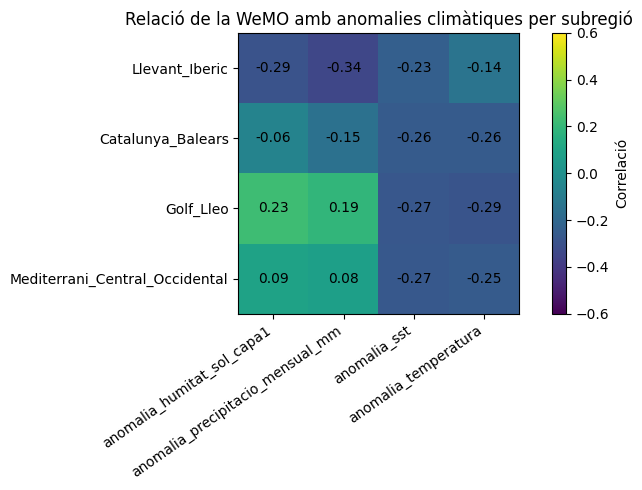

In [8]:
# La WeMO és especialment interessant perquè és un patró regional mediterrani.
wemo_sub = corr_subregions[corr_subregions["teleconnexio"] == "wemo"]

pivot_wemo = wemo_sub.pivot(
    index="subregio",
    columns="variable",
    values="correlacio"
)

ordre_subregions = [
    "Llevant_Iberic",
    "Catalunya_Balears",
    "Golf_Lleo",
    "Mediterrani_Central_Occidental",
]

pivot_wemo = pivot_wemo.reindex(ordre_subregions)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot_wemo, vmin=-0.6, vmax=0.6)

ax.set_xticks(range(len(pivot_wemo.columns)))
ax.set_yticks(range(len(pivot_wemo.index)))
ax.set_xticklabels(pivot_wemo.columns, rotation=35, ha="right")
ax.set_yticklabels(pivot_wemo.index)

for i in range(len(pivot_wemo.index)):
    for j in range(len(pivot_wemo.columns)):
        ax.text(j, i, f"{pivot_wemo.iloc[i, j]:.2f}", ha="center", va="center")

ax.set_title("Relació de la WeMO amb anomalies climàtiques per subregió")
plt.colorbar(im, ax=ax, label="Correlació")

plt.tight_layout()
plt.savefig(FIG / "03_heatmap_wemo_subregions.png", dpi=300)
plt.show()

In [9]:
nao_phase_summary = (
    df.groupby(["estacio", "fase_nao"], observed=True)[
        [
            "anomalia_temperatura",
            "anomalia_precipitacio_mensual_mm",
            "anomalia_humitat_sol_capa1",
            "anomalia_sst",
        ]
    ]
    .mean()
    .reset_index()
)

display(nao_phase_summary)
nao_phase_summary.to_csv(PROC / "03_resum_fase_nao_v2.csv", index=False)

,estacio,fase_nao,anomalia_temperatura,anomalia_precipitacio_mensual_mm,anomalia_humitat_sol_capa1,anomalia_sst
0,Winter,Negative,-0.384497,15.743366,0.013620,-0.190876
1,Winter,Neutral,-0.287417,6.027694,0.009341,-0.048597
2,Winter,Positive,0.251833,-8.397844,-0.008640,0.093656
3,Spring,Negative,-0.255919,8.011825,0.012929,-0.160841
4,Spring,Neutral,-0.005621,1.322361,-0.000978,0.031544
5,Spring,Positive,0.199887,-6.874983,-0.009419,0.106739
6,Summer,Negative,0.098244,1.488891,0.001671,0.119339
7,Summer,Neutral,0.231553,-5.453901,-0.012406,0.116089
8,Summer,Positive,-0.227259,0.426303,0.003193,-0.204728
9,Autumn,Negative,-0.130779,8.592526,0.007225,-0.017543


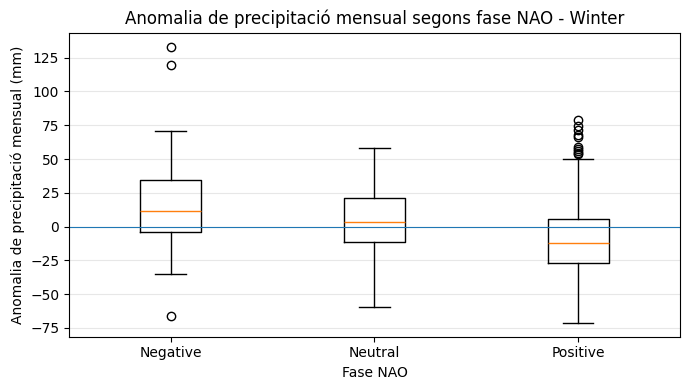

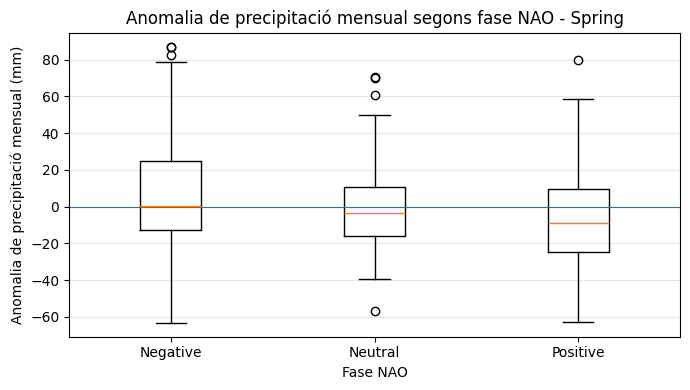

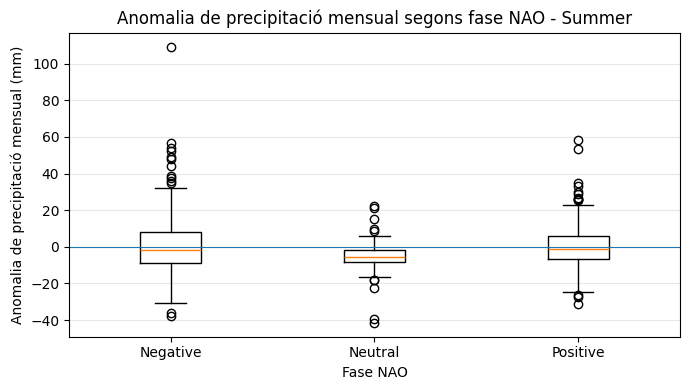

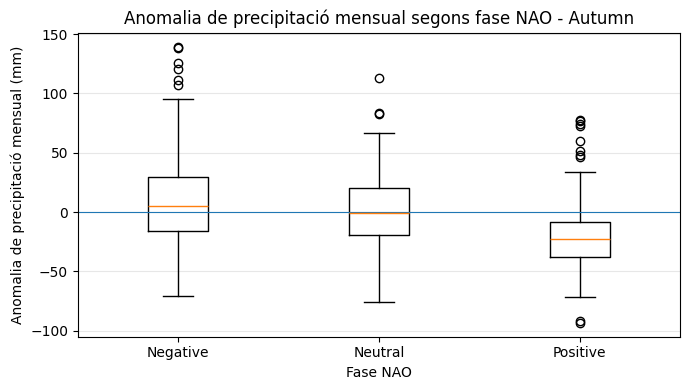

In [10]:
for estacio in ordre_estacions:
    subset = df[df["estacio"] == estacio]

    data = [
        subset[subset["fase_nao"] == fase]["anomalia_precipitacio_mensual_mm"].dropna()
        for fase in ordre_fases
    ]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.boxplot(data, tick_labels=ordre_fases)
    ax.axhline(0, linewidth=0.8)
    ax.set_title(f"Anomalia de precipitació mensual segons fase NAO - {estacio}")
    ax.set_xlabel("Fase NAO")
    ax.set_ylabel("Anomalia de precipitació mensual (mm)")
    ax.grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIG / f"03_boxplot_nao_precipitacio_{estacio}.png", dpi=300)
    plt.show()

In [11]:
wemo_phase_summary = (
    df.groupby(["estacio", "fase_wemo"], observed=True)[
        [
            "anomalia_temperatura",
            "anomalia_precipitacio_mensual_mm",
            "anomalia_humitat_sol_capa1",
            "anomalia_sst",
        ]
    ]
    .mean()
    .reset_index()
)

display(wemo_phase_summary)
wemo_phase_summary.to_csv(PROC / "03_resum_fase_wemo_v2.csv", index=False)

,estacio,fase_wemo,anomalia_temperatura,anomalia_precipitacio_mensual_mm,anomalia_humitat_sol_capa1,anomalia_sst
0,Winter,Negative,0.116845,1.612224,0.004558,0.027385
1,Winter,Neutral,-0.413842,3.263613,0.003968,-0.129704
2,Winter,Positive,0.333794,-4.576798,-0.007559,0.111704
3,Spring,Negative,0.279386,-0.708840,0.002871,0.168883
4,Spring,Neutral,0.173059,-5.437801,-0.011599,0.076995
5,Spring,Positive,-0.587847,7.078257,0.008911,-0.324476
6,Summer,Negative,0.294842,-1.763723,-0.003030,0.236191
7,Summer,Neutral,-0.187762,0.431132,0.002449,-0.140692
8,Summer,Positive,-0.135424,1.685336,0.000734,-0.120778
9,Autumn,Negative,0.431349,2.595028,0.001632,0.330967


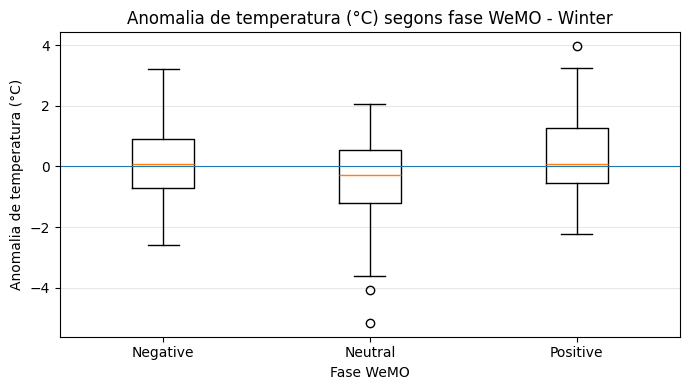

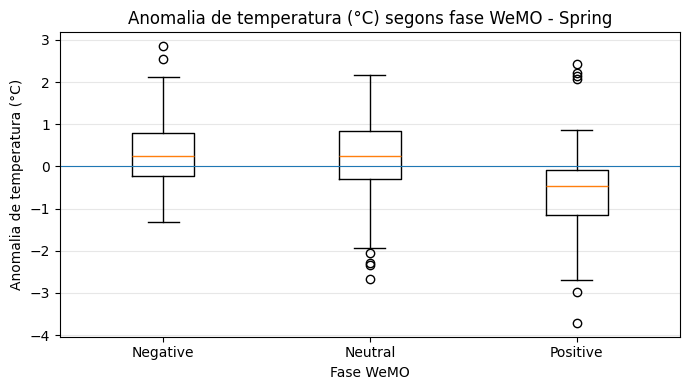

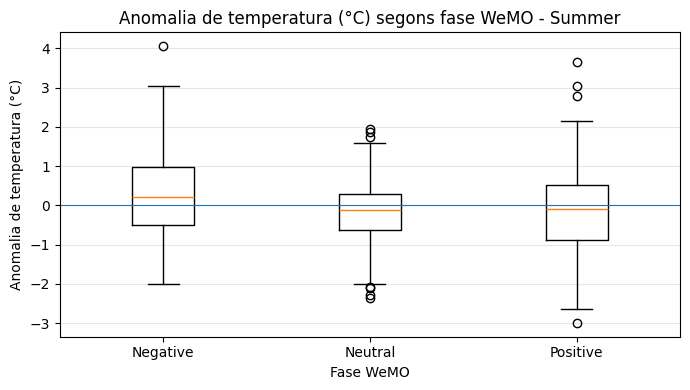

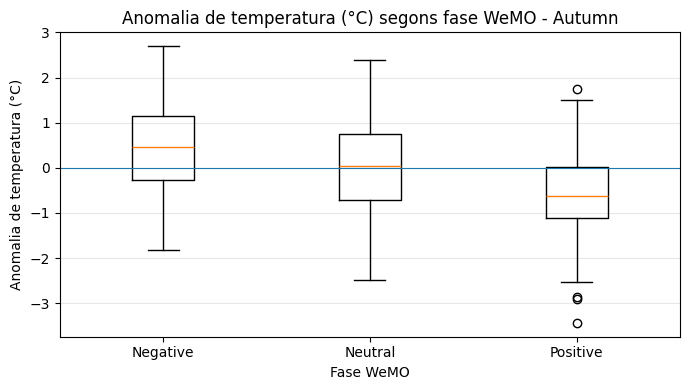

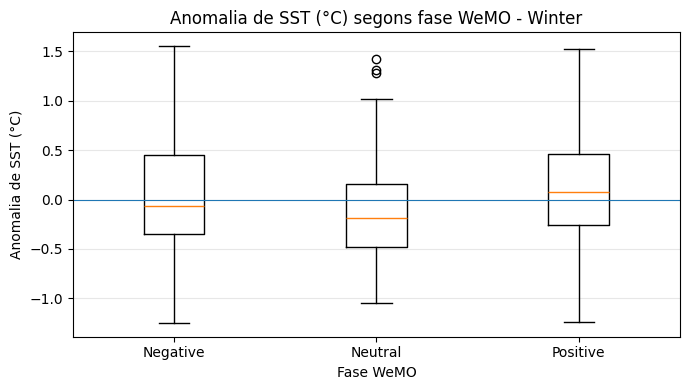

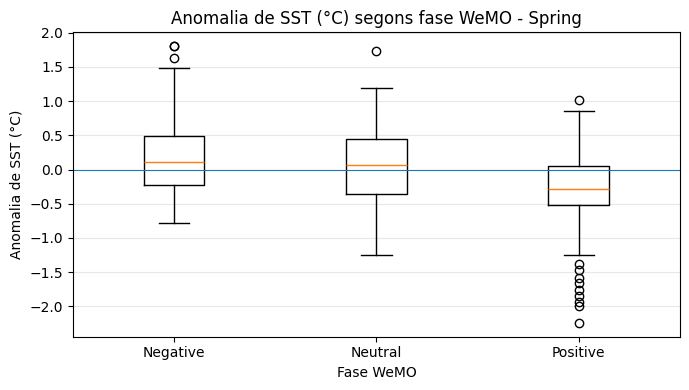

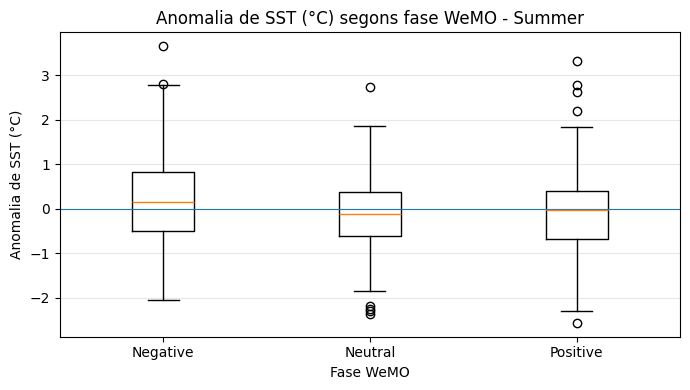

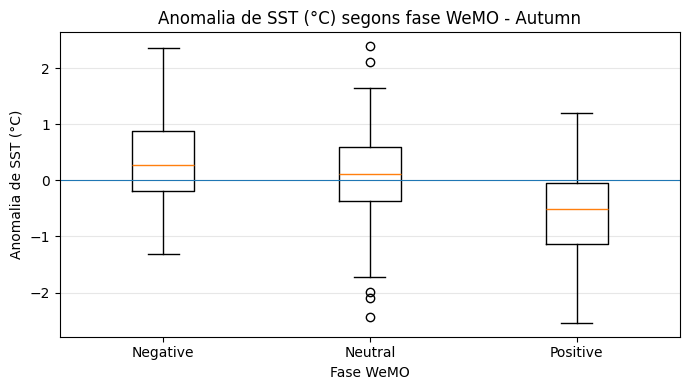

In [12]:
for variable, ylabel in [
    ("anomalia_temperatura", "Anomalia de temperatura (°C)"),
    ("anomalia_sst", "Anomalia de SST (°C)")
]:
    for estacio in ordre_estacions:
        subset = df[df["estacio"] == estacio]

        data = [
            subset[subset["fase_wemo"] == fase][variable].dropna()
            for fase in ordre_fases
        ]

        fig, ax = plt.subplots(figsize=(7, 4))
        ax.boxplot(data, tick_labels=ordre_fases)
        ax.axhline(0, linewidth=0.8)
        ax.set_title(f"{ylabel} segons fase WeMO - {estacio}")
        ax.set_xlabel("Fase WeMO")
        ax.set_ylabel(ylabel)
        ax.grid(True, axis="y", alpha=0.3)

        plt.tight_layout()
        plt.savefig(FIG / f"03_boxplot_wemo_{variable}_{estacio}.png", dpi=300)
        plt.show()

In [13]:
enso_phase_summary = (
    df.groupby(["estacio", "fase_enso"], observed=True)[
        [
            "anomalia_temperatura",
            "anomalia_precipitacio_mensual_mm",
            "anomalia_humitat_sol_capa1",
            "anomalia_sst",
        ]
    ]
    .mean()
    .reset_index()
)

display(enso_phase_summary)
enso_phase_summary.to_csv(PROC / "03_resum_fase_enso_v2.csv", index=False)

,estacio,fase_enso,anomalia_temperatura,anomalia_precipitacio_mensual_mm,anomalia_humitat_sol_capa1,anomalia_sst
0,Winter,La Nina,-0.125228,1.253733,-0.000379,-0.059492
1,Winter,Neutral,0.177777,0.701805,0.001726,-0.064262
2,Winter,El Nino,-0.007098,-2.038327,-0.001031,0.123038
3,Spring,La Nina,0.080044,6.762035,0.006574,0.012004
4,Spring,Neutral,0.089087,-0.328480,0.002113,0.092147
5,Spring,El Nino,-0.257013,-7.050477,-0.011395,-0.185613
6,Summer,La Nina,-0.003098,-1.257647,0.002445,0.055775
7,Summer,Neutral,0.114481,-1.415071,-0.001705,0.123493
8,Summer,El Nino,-0.226263,3.925512,0.001280,-0.295563
9,Autumn,La Nina,-0.151826,-6.717860,-0.007990,-0.062397


In [14]:
episodis = (
    df.groupby(["periode", "subregio"], observed=True)[
        [
            "mes_molt_calid",
            "mes_molt_sec",
            "sol_molt_sec",
            "episodi_calid_i_sec",
            "episodi_calid_i_sol_sec",
        ]
    ]
    .mean()
    .reset_index()
)

# Passem proporcions a percentatges.
for col in [
    "mes_molt_calid",
    "mes_molt_sec",
    "sol_molt_sec",
    "episodi_calid_i_sec",
    "episodi_calid_i_sol_sec",
]:
    episodis[col] = episodis[col] * 100

display(episodis)
episodis.to_csv(PROC / "03_episodis_periode_subregio_v2.csv", index=False)

,periode,subregio,mes_molt_calid,mes_molt_sec,sol_molt_sec,episodi_calid_i_sec,episodi_calid_i_sol_sec
0,1981-1990,Catalunya_Balears,5.000000,8.333333,22.500000,0.000000,0.833333
1,1981-1990,Golf_Lleo,12.500000,23.333333,19.166667,5.000000,3.333333
2,1981-1990,Llevant_Iberic,8.333333,5.000000,23.333333,0.833333,2.500000
3,1981-1990,Mediterrani_Central_Occidental,6.666667,11.666667,28.333333,0.833333,2.500000
4,1991-2000,Catalunya_Balears,10.833333,7.500000,24.166667,2.500000,4.166667
5,1991-2000,Golf_Lleo,16.666667,17.500000,15.000000,5.833333,2.500000
6,1991-2000,Llevant_Iberic,10.833333,5.000000,35.833333,1.666667,4.166667
7,1991-2000,Mediterrani_Central_Occidental,7.500000,7.500000,25.833333,1.666667,2.500000
8,2001-2010,Catalunya_Balears,12.500000,5.000000,29.166667,2.500000,6.666667
9,2001-2010,Golf_Lleo,23.333333,20.833333,23.333333,6.666667,6.666667


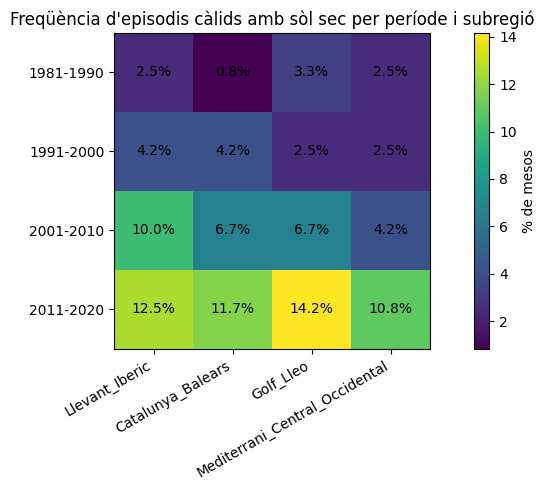

In [15]:
pivot_episodis = episodis.pivot(
    index="periode",
    columns="subregio",
    values="episodi_calid_i_sol_sec"
)

pivot_episodis = pivot_episodis.reindex(columns=ordre_subregions)

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(pivot_episodis)

ax.set_xticks(range(len(pivot_episodis.columns)))
ax.set_yticks(range(len(pivot_episodis.index)))
ax.set_xticklabels(pivot_episodis.columns, rotation=30, ha="right")
ax.set_yticklabels(pivot_episodis.index)

for i in range(len(pivot_episodis.index)):
    for j in range(len(pivot_episodis.columns)):
        ax.text(j, i, f"{pivot_episodis.iloc[i, j]:.1f}%", ha="center", va="center")

ax.set_title("Freqüència d'episodis càlids amb sòl sec per període i subregió")
plt.colorbar(im, ax=ax, label="% de mesos")

plt.tight_layout()
plt.savefig(FIG / "03_heatmap_episodis_calid_sol_sec.png", dpi=300)
plt.show()

## Conclusions principals

L'anàlisi mostra que les teleconnexions no tenen el mateix pes sobre totes les variables climàtiques.

La NAO és el patró que presenta una relació més clara amb la precipitació i la humitat del sòl, especialment durant l'hivern. Les fases positives de la NAO s'associen amb anomalies més seques, mentre que les fases negatives tendeixen a coincidir amb condicions més humides.

La WeMO mostra una relació més marcada amb la temperatura i la temperatura superficial del mar, especialment a primavera i tardor. Aquesta relació és coherent amb el seu caràcter més regional dins l'àmbit mediterrani occidental.

El RONI, utilitzat com a indicador d'ENSO, presenta correlacions globals febles. Això suggereix que, en aquest àmbit regional i mensual, ENSO té un paper menys directe que la NAO o la WeMO.

Finalment, els episodis càlids amb sòl sec augmenten clarament en el període 2011-2020, fet que pot constituir un bon focus narratiu per a la visualització final.